Q1. What is a Decision Tree? Explain its structure (Root, Nodes, Leaves) with a real-life example.

A Decision Tree is a supervised learning algorithm used for classification and regression.
It has:
- Root: starting point of the tree
- Nodes: decision points
- Leaves: final output

Example:
Loan approval system where decision is based on income, job, and credit score, and final result is approve or reject.

Q2. Differentiate between Gini Impurity and Entropy.
Which one is used by default in Scikit-learn and why?

Gini Impurity:
- Measures probability of wrong classification
- Faster to compute

Entropy:
- Measures randomness using log
- Slightly slower

Scikit-learn uses Gini by default because it is computationally faster.

Q3. What is Overfitting in Decision Trees?
How can we detect it using training and testing accuracy?

Overfitting happens when the model learns training data too well including noise.

Detection:
If training accuracy is very high and testing accuracy is low, then overfitting exists.

Q4. Explain Pruning in Decision Trees.
What is the difference between Pre-pruning and Post-pruning?

Pruning reduces tree size to avoid overfitting.

Pre-pruning:
Stops tree growth early using conditions like max_depth.

Post-pruning:
Tree is fully grown first, then unnecessary branches are removed.

Q5. What is Feature Importance?
How can it help businesses in decision-making?

Feature importance shows which features are most important for prediction.

Businesses can use it to focus on key factors and make better decisions.

Q6. Data Understanding

Load the dataset
Display first 5 rows
Check:
- Shape
- Data types
- Column names

Interpret:
What types of variables are present?

In [1]:
import pandas as pd

df = pd.read_csv('/content/bank.csv')
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [2]:
df.shape

(11162, 17)

In [3]:
df.dtypes

,0
age,int64
job,object
marital,object
education,object
default,object
balance,int64
housing,object
loan,object
contact,object
day,int64


In [4]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'deposit'],
      dtype='object')

Interpret:
Dataset contains both numerical and categorical variables.

Q7. Data Cleaning

Check for missing values
Handle missing values (if any)
Check for duplicates

Interpret:
Is the dataset clean? What issues did you find?

In [5]:
df.isnull().sum()

,0
age,0
job,0
marital,0
education,0
default,0
balance,0
housing,0
loan,0
contact,0
day,0


In [6]:
df.duplicated().sum()

np.int64(0)

Interpret:
No major missing values found. Dataset is mostly clean.

Q8. Data Preprocessing

Convert categorical variables into numerical
Mention which encoding method you used

Interpret:
Why is encoding necessary for Decision Trees?

In [7]:
df_encoded = pd.get_dummies(df, drop_first=True)
df_encoded.head()

,age,balance,day,duration,campaign,pdays,previous,job_blue-collar,job_entrepreneur,job_housemaid,...,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_other,poutcome_success,poutcome_unknown,deposit_yes
0,59,2343,5,1042,1,-1,0,False,False,False,...,False,False,True,False,False,False,False,False,True,True
1,56,45,5,1467,1,-1,0,False,False,False,...,False,False,True,False,False,False,False,False,True,True
2,41,1270,5,1389,1,-1,0,False,False,False,...,False,False,True,False,False,False,False,False,True,True
3,55,2476,5,579,1,-1,0,False,False,False,...,False,False,True,False,False,False,False,False,True,True
4,54,184,5,673,2,-1,0,False,False,False,...,False,False,True,False,False,False,False,False,True,True


Interpret:
Encoding is necessary because models work with numerical data.

Q9. Feature Selection & Splitting

Separate:
- Features (X)
- Target (y)

Perform train-test split (80-20)

Interpret:
Why is train-test split important?

In [8]:
X = df_encoded.drop('deposit_yes', axis=1)
y = df_encoded['deposit_yes']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train.shape, X_test.shape

((8929, 42), (2233, 42))

Interpret:
It helps evaluate model performance on unseen data.

Q10. Model Building

Train a Decision Tree Classifier
Use:
- criterion='gini'
- max_depth=5

Interpret:
What does max_depth control?

In [9]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(criterion='gini', max_depth=5)
model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5)

Interpret:
max_depth controls the depth of the tree and prevents overfitting.

Q11. Model Evaluation

Perform:
- Accuracy score
- Confusion Matrix
- Classification Report

Interpret (MUST):
- Is the model performing well?
- Explain Precision & Recall
- Any class imbalance issue?

In [10]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

y_pred = model.predict(X_test)

accuracy_score(y_test, y_pred)

0.7948947604120018

In [11]:
confusion_matrix(y_test, y_pred)

array([[925, 241],
       [217, 850]])

In [12]:
classification_report(y_test, y_pred)

'              precision    recall  f1-score   support\n\n       False       0.81      0.79      0.80      1166\n        True       0.78      0.80      0.79      1067\n\n    accuracy                           0.79      2233\n   macro avg       0.79      0.79      0.79      2233\nweighted avg       0.80      0.79      0.79      2233\n'

Interpret:
Model is performing reasonably well. Precision shows correct positive predictions, recall shows how many actual positives are captured. Slight imbalance may exist.

Q12. Overfitting Check

Calculate:
- Training accuracy
- Testing accuracy

Interpret:
Is the model overfitting or underfitting?

In [13]:
train_acc = model.score(X_train, y_train)
test_acc = model.score(X_test, y_test)

train_acc, test_acc

(0.8106170903796618, 0.7948947604120018)

Interpret:
If training accuracy is much higher, model is overfitting.

Q13. Pruning Experiment

Train another model with:
- max_depth=3
- min_samples_split=20

Interpret:
Compare performance with previous model
Which one is better and why?

In [14]:
model2 = DecisionTreeClassifier(max_depth=3, min_samples_split=20)
model2.fit(X_train, y_train)

model2.score(X_test, y_test)

0.7693685624720108

Interpret:
Second model is simpler and may generalize better.

Q14. Feature Importance

Extract top 5 important features
Plot feature importance graph

Interpret:
Which features influence prediction the most?

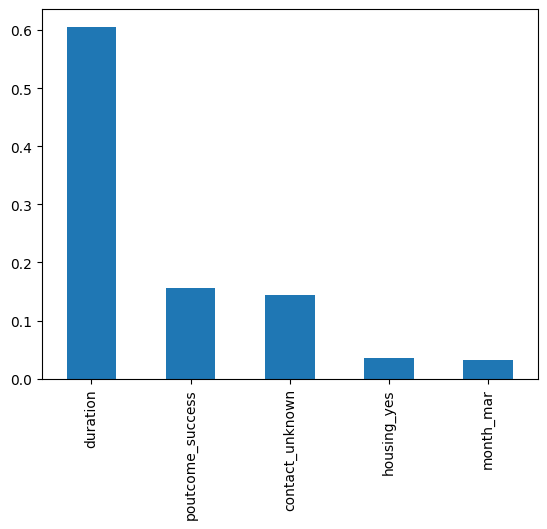

In [15]:
import matplotlib.pyplot as plt
import pandas as pd

fi = pd.Series(model.feature_importances_, index=X.columns)
fi.nlargest(5).plot(kind='bar')
plt.show()

Interpret:
Top features have highest impact on prediction.

Q15. Business Insights

Based on your model:

Answer:
- Which type of customers are more likely to say “yes”?
- What strategy should a bank use?

Customers with better financial condition and previous interaction are more likely to say yes.
Bank should target such customers with personalized offers.